In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage
import pandas as pd
import os
import glob
import math
import random
import matplotlib.pyplot as plt
csv_filename = "Results/V3.csv"

In [2]:
df = pd.read_csv(csv_filename)
print(df.head())

  Imagen_idobject  Scene_coordinate_system  Area_px  Area_mm2  Perimetro_px  \
0         xy003_0                      0.0     1263  0.591155    147.112698   
1         xy003_1                      0.0     1080  0.505501    128.769552   
2         xy003_2                      0.0     4396  2.057577    279.982755   
3         xy003_3                      0.0     2923  1.368129    259.012193   
4         xy003_4                      0.0     1425  0.666981    162.124890   

   Perimetro_mm  Diametro_px  Diametro_mm  Escala_mm_por_px  \
0      3.182727    40.101141     0.867573          0.021635   
1      2.785880    37.082323     0.802262          0.021635   
2      6.057319    74.814177     1.618576          0.021635   
3      5.603629    61.005567     1.319832          0.021635   
4      3.507510    42.595379     0.921535          0.021635   

   Porcentaje_no_pintado   Coordenades  Class_id  aspect_ratio  
0              47.057477   [[90, 498]]         8      0.673469  
1              4

Separating the values 

In [3]:
df['Imagen_idobject_substr'] = df['Imagen_idobject'].str[2:5]
df['Imagen_idobject_substr'] = df['Imagen_idobject_substr'].str.replace('_', '')
df['Imagen_idobject_substr'] = df['Imagen_idobject_substr'].astype(int)
df['Coordenate_type'] = df['Imagen_idobject'].str[0:2]
df['Coordenate_type'] = df['Coordenate_type'].astype(str)

df['X_Coordenate'] = None
df['Y_Coordenate'] = None
df['Z_Coordenate'] = None

#Extract the coordinates of the object xy, xz, yz
df.loc[df['Coordenate_type'] == 'xy', 'X_Coordenate'] = df['Coordenades'].str.extract(r'\[\[(\d+),')[0].astype(int)
df.loc[df['Coordenate_type'] == 'xy', 'Y_Coordenate'] = df['Coordenades'].str.extract(r',\s*(\d+)\]\]')[0].astype(int)
df.loc[df['Coordenate_type'] == 'xy', 'Z_Coordenate'] = 0

df.loc[df['Coordenate_type'] == 'xz', 'X_Coordenate'] = df['Coordenades'].str.extract(r'\[\[(\d+),')[0].astype(int)
df.loc[df['Coordenate_type'] == 'xz', 'Y_Coordenate'] = 0
df.loc[df['Coordenate_type'] == 'xz', 'Z_Coordenate'] = df['Coordenades'].str.extract(r',\s*(\d+)\]\]')[0].astype(int)

df.loc[df['Coordenate_type'] == 'yz', 'X_Coordenate'] = 0
df.loc[df['Coordenate_type'] == 'yz', 'Y_Coordenate'] = df['Coordenades'].str.extract(r'\[\[(\d+),')[0].astype(int)
df.loc[df['Coordenate_type'] == 'yz', 'Z_Coordenate'] = df['Coordenades'].str.extract(r',\s*(\d+)\]\]')[0].astype(int)

In [4]:
print(df.head())

  Imagen_idobject  Scene_coordinate_system  Area_px  Area_mm2  Perimetro_px  \
0         xy003_0                      0.0     1263  0.591155    147.112698   
1         xy003_1                      0.0     1080  0.505501    128.769552   
2         xy003_2                      0.0     4396  2.057577    279.982755   
3         xy003_3                      0.0     2923  1.368129    259.012193   
4         xy003_4                      0.0     1425  0.666981    162.124890   

   Perimetro_mm  Diametro_px  Diametro_mm  Escala_mm_por_px  \
0      3.182727    40.101141     0.867573          0.021635   
1      2.785880    37.082323     0.802262          0.021635   
2      6.057319    74.814177     1.618576          0.021635   
3      5.603629    61.005567     1.319832          0.021635   
4      3.507510    42.595379     0.921535          0.021635   

   Porcentaje_no_pintado   Coordenades  Class_id  aspect_ratio  \
0              47.057477   [[90, 498]]         8      0.673469   
1             

In [5]:
csv_filename = "Results/merged_bubbles_PU122_V2.csv"
df.to_csv(csv_filename, index=False)

Creating a new table based of the images, instead of single bubble only from XY

In [9]:
    # Count the occurrences of each unique value in the 'Imagen_idobject_substr' column
    df_xy = df[(df['Coordenate_type'] == 'xy') & (df['Imagen_idobject_substr'] > 7)] 
    count_table = df_xy['Imagen_idobject_substr'].value_counts().reset_index()
    count_table.columns = ['Imagen_idobject_substr', 'Count']
    
    # Calculate the average 'Porcentaje_no_pintado' for each 'Imagen_idobject_substr'
    average_porcentaje_no_pintado = df_xy.groupby('Imagen_idobject_substr')['Porcentaje_no_pintado'].mean().reset_index()
    
    # Merge the average 'Porcentaje_no_pintado' with the count table
    count_table = pd.merge(count_table, average_porcentaje_no_pintado, on='Imagen_idobject_substr')
    
    # Sort the table by 'Imagen_idobject_substr'
    count_table = count_table.sort_values(by='Imagen_idobject_substr')
    # Convert 'Imagen_idobject_substr' to numeric and sort the table by it
    count_table['Imagen_idobject_substr'] = pd.to_numeric(count_table['Imagen_idobject_substr'])
    count_table = count_table.sort_values(by='Imagen_idobject_substr')
    # Add an extra column with values increasing by 0.50505 starting from -23.48485 for Imagen_idobject_substr starting from 3
    start_value = -23.48485
    increment = 0.50505
    count_table['Scene_coordinate_system'] = start_value + increment * (count_table['Imagen_idobject_substr'] - 3)
    # Minimum and maximum values of 'Diametro_mm' for each 'Imagen_idobject_substr'
    min_diametro_mm = df_xy.groupby('Imagen_idobject_substr')['Diametro_mm'].min().reset_index()
    max_diametro_mm = df_xy.groupby('Imagen_idobject_substr')['Diametro_mm'].max().reset_index()
    average_diametro_mm = df_xy.groupby('Imagen_idobject_substr')['Diametro_mm'].mean().reset_index()
    average_area_mm2 = df_xy.groupby('Imagen_idobject_substr')['Area_mm2'].mean().reset_index()
    mode_class_id = df_xy.groupby('Imagen_idobject_substr')['Class_id'].agg(lambda x: x.value_counts().index[0]).reset_index()
    # Merge the minimum and maximum values of 'Diametro_mm' with the count table
    count_table = pd.merge(count_table, min_diametro_mm, on='Imagen_idobject_substr')
    count_table = pd.merge(count_table, max_diametro_mm, on='Imagen_idobject_substr')
    count_table = pd.merge(count_table, average_diametro_mm, on='Imagen_idobject_substr')
    count_table = pd.merge(count_table, mode_class_id, on='Imagen_idobject_substr')
    count_table = pd.merge(count_table, average_area_mm2, on='Imagen_idobject_substr')
    # Rename the columns
    count_table = count_table.rename(columns={'Diametro_mm_x': 'Min_Diametro_mm', 'Diametro_mm_y': 'Max_Diametro_mm',
    'Average_DiametAo_mm': 'Average_Diametro_mm', 'Class_id': 'Mode_Class_id'})
    # Print the first 5 rows of the count table




    
    print(count_table.head())


   Imagen_idobject_substr  Count  Porcentaje_no_pintado  \
0                       8    449              17.965141   
1                       9    466              16.736613   
2                      10    530              17.412212   
3                      11    615              17.541165   
4                      12    726              17.001388   

   Scene_coordinate_system  Min_Diametro_mm  Max_Diametro_mm  Diametro_mm  \
0                -20.95960         0.207143         2.472014     0.980982   
1                -20.45455         0.189095         2.446448     0.938531   
2                -19.94950         0.190664         2.462715     0.877450   
3                -19.44445         0.190664         2.242191     0.824307   
4                -18.93940         0.190664         2.414943     0.784910   

   Mode_Class_id  Area_mm2  
0              1  0.937868  
1              1  0.882044  
2              1  0.801152  
3              1  0.689221  
4              1  0.596777  


Plot the results of X Y 

C:\Users\yourk\AppData\Local\Temp\ipykernel_18816\156565210.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_diametro_mm_per_group = count_table.groupby('Group')['Diametro_mm'].mean()
C:\Users\yourk\AppData\Local\Temp\ipykernel_18816\156565210.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top3_groups = count_table.groupby('Group')['Diametro_mm'].mean().nlargest(3).index


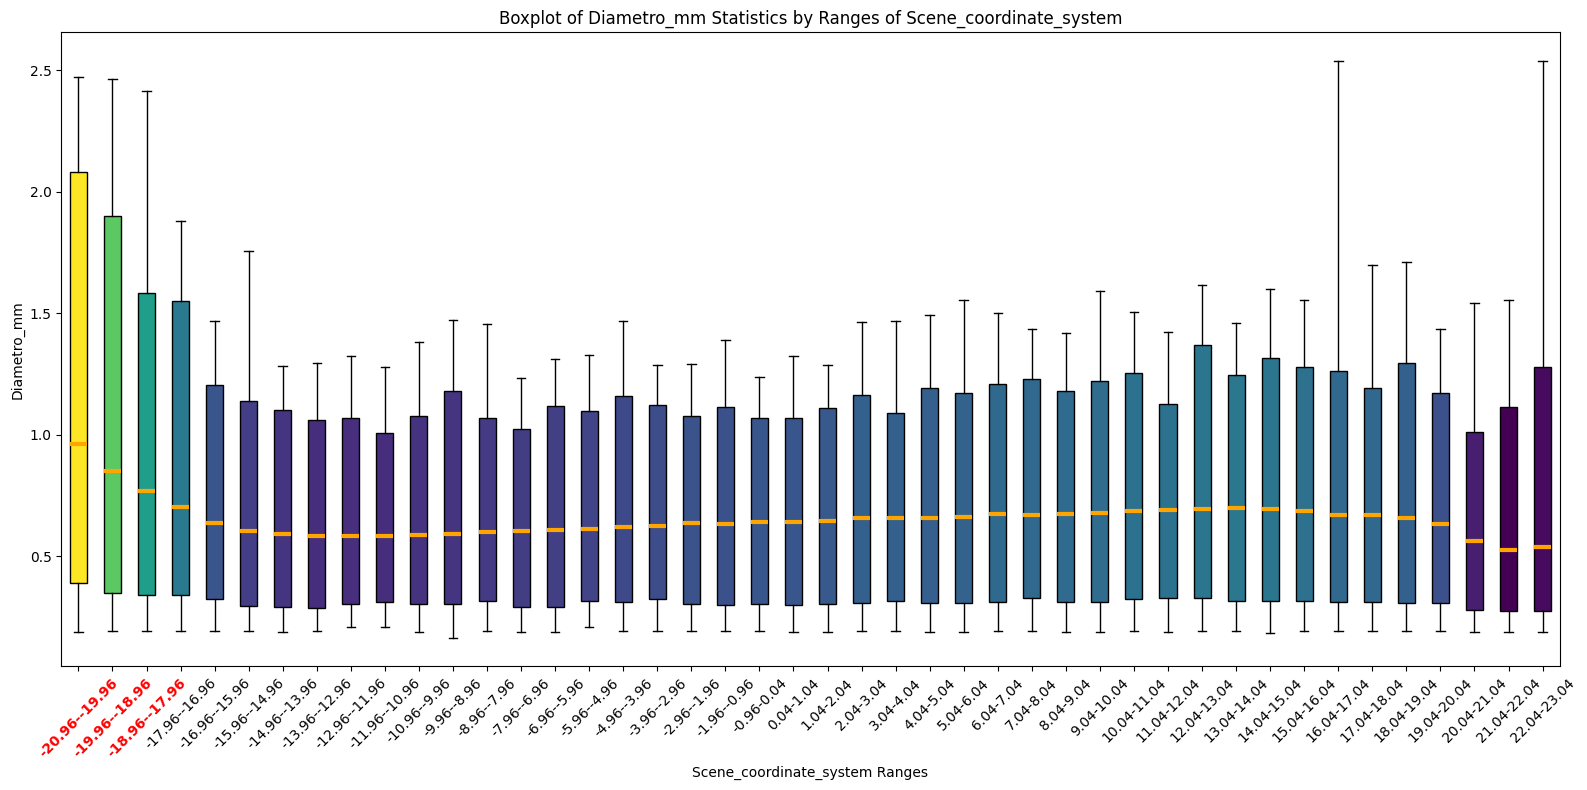

In [24]:
# Create bins for grouping 'Scene_coordinate_system' into ranges
bins = np.arange(count_table['Scene_coordinate_system'].min(), 
                 count_table['Scene_coordinate_system'].max() + 1, 
                 1)

# Assign each 'Scene_coordinate_system' to a bin range for each scene
count_table['Group'] = pd.cut(count_table['Scene_coordinate_system'], bins=bins, right=False)

# Prepare data for the boxplot
boxplot_data = []

# Loop through each group and collect min, max, and average for boxplot
for group in count_table['Group'].unique():
    group_data = count_table[count_table['Group'] == group]
    boxplot_data.append(group_data[['Min_Diametro_mm', 'Max_Diametro_mm', 'Diametro_mm']].values.flatten())

# Plot the boxplot
plt.figure(figsize=(16, 8))

# Create the boxplot with customized median line
boxplot = plt.boxplot(
    boxplot_data,
    patch_artist=True,
    showfliers=False,  
    medianprops=dict(color='orange', linewidth=3)  
)

# Customize X-axis with group ranges
group_labels = [f"{interval.left:.2f}-{interval.right:.2f}" for interval in count_table['Group'].cat.categories]
plt.xticks(ticks=range(1, len(group_labels) + 1), labels=group_labels, rotation=45)

# Add labels and title
plt.xlabel('Scene_coordinate_system Ranges')
plt.ylabel('Diametro_mm')
plt.title('Boxplot of Diametro_mm Statistics by Ranges of Scene_coordinate_system')

# Add color to each boxplot based on the average Diametro_mm for each group
# Get the average Diametro_mm for each group (bin)
avg_diametro_mm_per_group = count_table.groupby('Group')['Diametro_mm'].mean()

# Normalize the average Diametro_mm values to map to the colormap
norm = plt.Normalize(vmin=avg_diametro_mm_per_group.min(), vmax=avg_diametro_mm_per_group.max())
cmap = plt.cm.viridis

# Assign colors to boxes based on the average Diametro_mm for each group
for i, patch in enumerate(boxplot['boxes']):
    group = count_table['Group'].cat.categories[i]
    avg_diametro_mm = avg_diametro_mm_per_group[group]
    color = cmap(norm(avg_diametro_mm))
    patch.set_facecolor(color)
# Highlight the top 3 groups with the highest average Diametro_mm
top3_groups = count_table.groupby('Group')['Diametro_mm'].mean().nlargest(3).index
for i, group in enumerate(count_table['Group'].cat.categories):
    if group in top3_groups:
        plt.gca().get_xticklabels()[i].set_color('red')
        plt.gca().get_xticklabels()[i].set_fontweight('bold')


# Display the plot
plt.tight_layout()
plt.show()


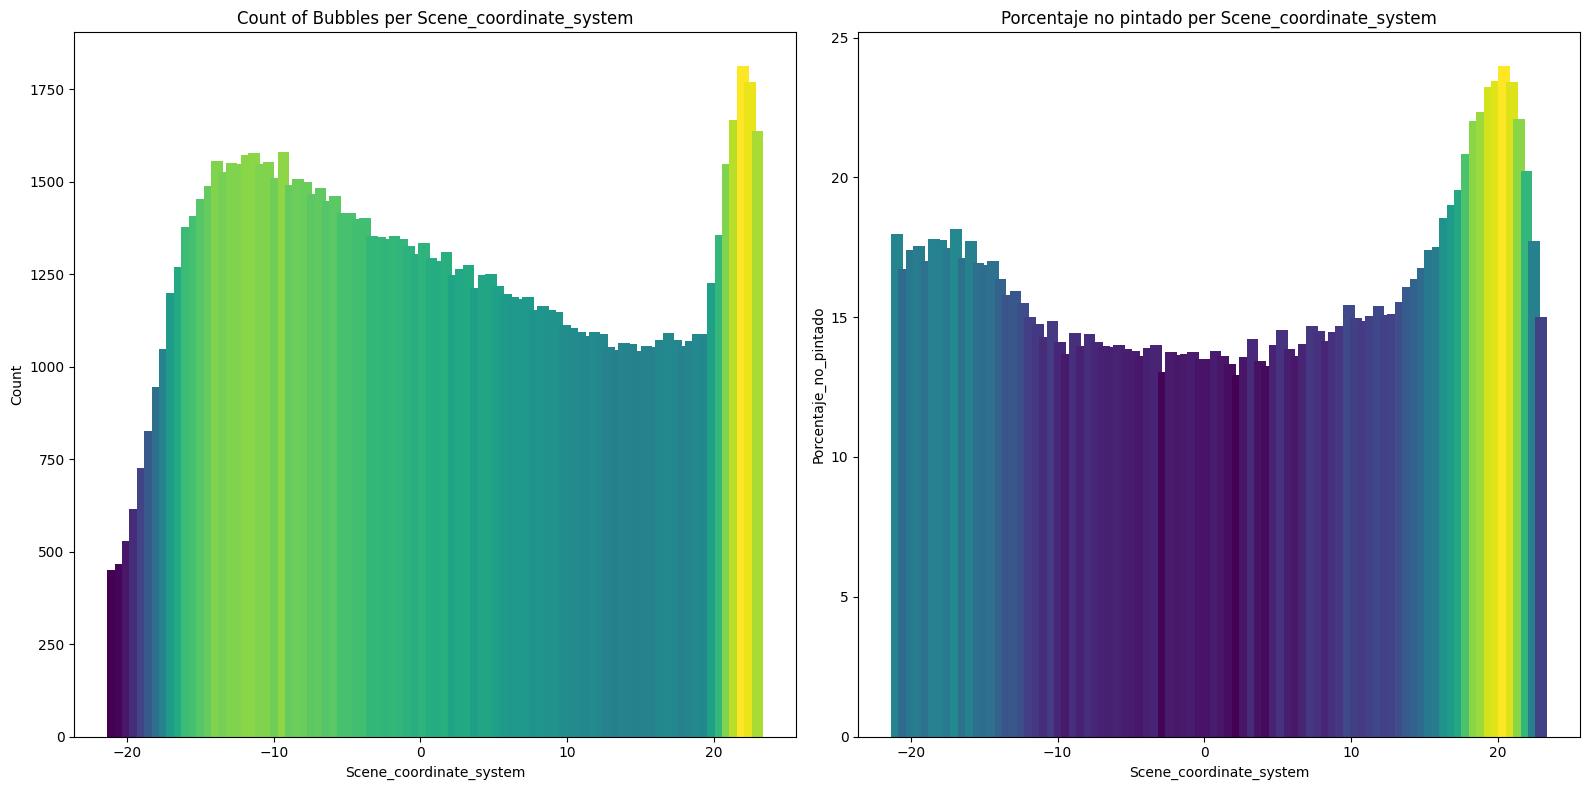

In [25]:
# Define a function to determine the color based on the count value using a gradient
def get_color(value, min_value, max_value):
    # Normalize the value to be between 0 and 1
    normalized_value = (value - min_value) / (max_value - min_value)
    # Convert the normalized value to a color using a colormap
    colormap = plt.cm.viridis
    return colormap(normalized_value)

# Get the minimum and maximum values of the 'Count' column
min_count = count_table['Count'].min()
max_count = count_table['Count'].max()

# Apply the color function to each value in the 'Count' column
colors_count = count_table['Count'].apply(lambda x: get_color(x, min_count, max_count))

# Get the minimum and maximum values of the 'Porcentaje_no_pintado' column
min_porcentaje = count_table['Porcentaje_no_pintado'].min()
max_porcentaje = count_table['Porcentaje_no_pintado'].max()

# Apply the color function to each value in the 'Porcentaje_no_pintado' column
colors_porcentaje = count_table['Porcentaje_no_pintado'].apply(lambda x: get_color(x, min_porcentaje, max_porcentaje))
# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Plot the count data
axs[0].bar(count_table['Scene_coordinate_system'], count_table['Count'], color=colors_count)
axs[0].set_xlabel('Scene_coordinate_system')
axs[0].set_ylabel('Count')
axs[0].set_title('Count of Bubbles per Scene_coordinate_system')

# Plot the porcentaje no pintado data
axs[1].bar(count_table['Scene_coordinate_system'], count_table['Porcentaje_no_pintado'], color=colors_porcentaje)
axs[1].set_xlabel('Scene_coordinate_system')
axs[1].set_ylabel('Porcentaje_no_pintado')
axs[1].set_title('Porcentaje no pintado per Scene_coordinate_system')

# Adjust layout
plt.tight_layout()
plt.show()


Creating a new table, based of the images XZ

In [10]:
  # Count the occurrences of each unique value in the 'Imagen_idobject_substr' column
from numpy import average


df_xz =df[(df['Coordenate_type'] == 'xz')  & ((df['Imagen_idobject_substr'] > 7) & (df['Imagen_idobject_substr'] < 94))]
count_table_xz = df_xz['Imagen_idobject_substr'].value_counts().reset_index()
count_table_xz.columns = ['Imagen_idobject_substr', 'Count']
    
    # Calculate the average 'Porcentaje_no_pintado' for each 'Imagen_idobject_substr'
average_porcentaje_no_pintado_xz = df_xz.groupby('Imagen_idobject_substr')['Porcentaje_no_pintado'].mean().reset_index()
    
    # Merge the average 'Porcentaje_no_pintado' with the count table
count_table_xz = pd.merge(count_table_xz, average_porcentaje_no_pintado_xz, on='Imagen_idobject_substr')
    
    # Sort the table by 'Imagen_idobject_substr'
count_table_xz = count_table_xz.sort_values(by='Imagen_idobject_substr')
    # Convert 'Imagen_idobject_substr' to numeric and sort the table by it
count_table_xz['Imagen_idobject_substr'] = pd.to_numeric(count_table_xz['Imagen_idobject_substr'])
count_table_xz = count_table_xz.sort_values(by='Imagen_idobject_substr')
    # Add an extra column with values increasing by 0.50505 starting from -23.48485 for Imagen_idobject_substr starting from 3
start_value_xz = -30.00000
increment_xz = 0.60606
count_table_xz['Scene_coordinate_system'] = start_value_xz + increment_xz * count_table_xz['Imagen_idobject_substr']
    # Minimum and maximum values of 'Diametro_mm' for each 'Imagen_idobject_substr'
min_diametro_mm_xz = df_xz.groupby('Imagen_idobject_substr')['Diametro_mm'].min().reset_index()
max_diametro_mm_xz = df_xz.groupby('Imagen_idobject_substr')['Diametro_mm'].max().reset_index()
average_diametro_mm_xz = df_xz.groupby('Imagen_idobject_substr')['Diametro_mm'].mean().reset_index()
average_area_mm2_xz = df_xz.groupby('Imagen_idobject_substr')['Area_mm2'].mean().reset_index()
mode_class_id_xz = df_xz.groupby('Imagen_idobject_substr')['Class_id'].agg(lambda x: x.value_counts().index[0]).reset_index()
    # Merge the minimum and maximum values of 'Diametro_mm' with the count table
count_table_xz = pd.merge(count_table_xz, min_diametro_mm_xz, on='Imagen_idobject_substr')
count_table_xz = pd.merge(count_table_xz, max_diametro_mm_xz, on='Imagen_idobject_substr')
count_table_xz= pd.merge(count_table_xz, average_diametro_mm_xz, on='Imagen_idobject_substr')
count_table_xz = pd.merge(count_table_xz, mode_class_id_xz, on='Imagen_idobject_substr')
count_table_xz = pd.merge(count_table_xz, average_area_mm2_xz, on='Imagen_idobject_substr')
    # Rename the columns
count_table_xz = count_table_xz.rename(columns={'Diametro_mm_x': 'Min_Diametro_mm', 'Diametro_mm_y': 'Max_Diametro_mm',
    'Average_DiametAo_mm': 'Average_Diametro_mm', 'Class_id': 'Mode_Class_id'})
    # Print the first 5 rows of the count table
print(count_table_xz.head())

   Imagen_idobject_substr  Count  Porcentaje_no_pintado  \
0                       8   1944              31.181966   
1                       9   1847              30.059343   
2                      10   1752              29.201894   
3                      11   1713              27.648060   
4                      12   1694              26.177280   

   Scene_coordinate_system  Min_Diametro_mm  Max_Diametro_mm  Diametro_mm  \
0                -25.15152         0.088019         1.738062     0.444798   
1                -24.54546         0.088019         1.304390     0.460522   
2                -23.93940         0.111870         1.120298     0.480538   
3                -23.33334         0.088019         1.300729     0.491388   
4                -22.72728         0.088019         1.195194     0.501489   

   Mode_Class_id  Area_mm2  
0              1  0.169817  
1              1  0.181041  
2              2  0.196854  
3              2  0.205946  
4              2  0.214351  


C:\Users\yourk\AppData\Local\Temp\ipykernel_18816\1201195895.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means_xz = count_table_xz.groupby('Group')['Diametro_mm'].mean()


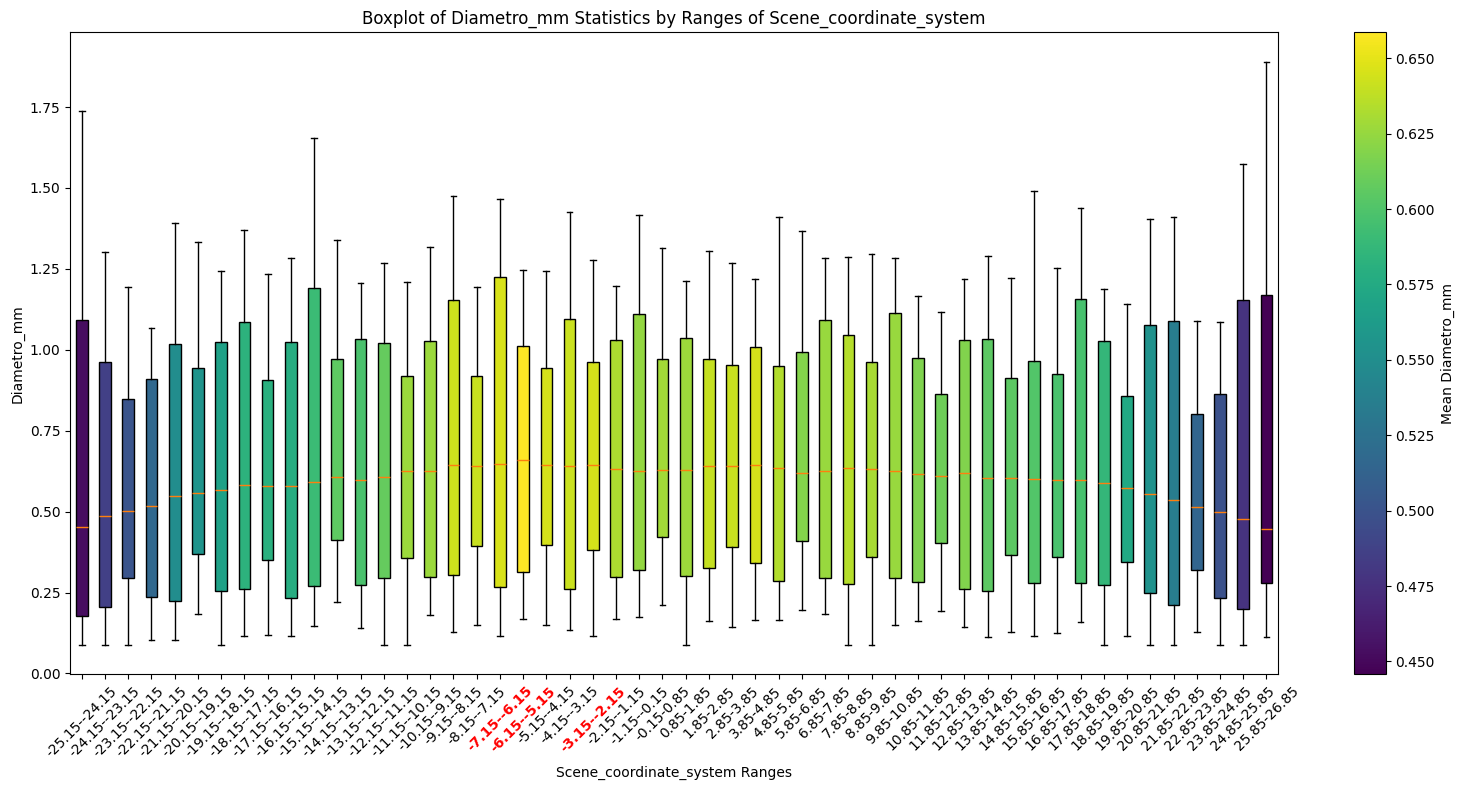

In [26]:
# Create bins for grouping 'Scene_coordinate_system' into ranges
bins = np.arange(count_table_xz['Scene_coordinate_system'].min(), 
                 count_table_xz['Scene_coordinate_system'].max() + 1, 
                 1)

# Assign each 'Scene_coordinate_system' to a bin range for each scene
count_table_xz['Group'] = pd.cut(count_table_xz['Scene_coordinate_system'], bins=bins, right=False)

# Prepare data for the boxplot
boxplot_data_xz = []

# Loop through each group and collect min, max, and average for boxplot
for group in count_table_xz['Group'].unique():
    group_data = count_table_xz[count_table_xz['Group'] == group]
    boxplot_data_xz.append(group_data[['Min_Diametro_mm', 'Max_Diametro_mm', 'Diametro_mm']].values.flatten())

# Get the means for each group to assign colors
means_xz = count_table_xz.groupby('Group')['Diametro_mm'].mean()

# Normalize the means to assign colors
norm = plt.Normalize(means_xz.min(), means_xz.max())
colors = plt.cm.viridis(norm(means_xz))


# Plot the boxplot
plt.figure(figsize=(16, 8))
boxplot = plt.boxplot(
    boxplot_data_xz,
    patch_artist=True,
    meanline=True,
)

# Customize X-axis with group ranges
group_labels_xz = [f"{interval.left:.2f}-{interval.right:.2f}" for interval in count_table_xz['Group'].cat.categories]
plt.xticks(ticks=range(1, len(group_labels_xz) + 1), labels=group_labels_xz, rotation=45)

# Add labels and title
plt.xlabel('Scene_coordinate_system Ranges')
plt.ylabel('Diametro_mm')
plt.title('Boxplot of Diametro_mm Statistics by Ranges of Scene_coordinate_system')

# Color each box based on the group's mean
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Highlight the top 3 groups with the highest average Diametro_mm
top3_groups_xz = means_xz.nlargest(3).index
for i, group in enumerate(count_table_xz['Group'].cat.categories):
    if group in top3_groups_xz:
        plt.gca().get_xticklabels()[i].set_color('red')
        plt.gca().get_xticklabels()[i].set_fontweight('bold')

# Add colorbar for the mean
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Mean Diametro_mm')

# Display the plot
plt.tight_layout()
plt.show()



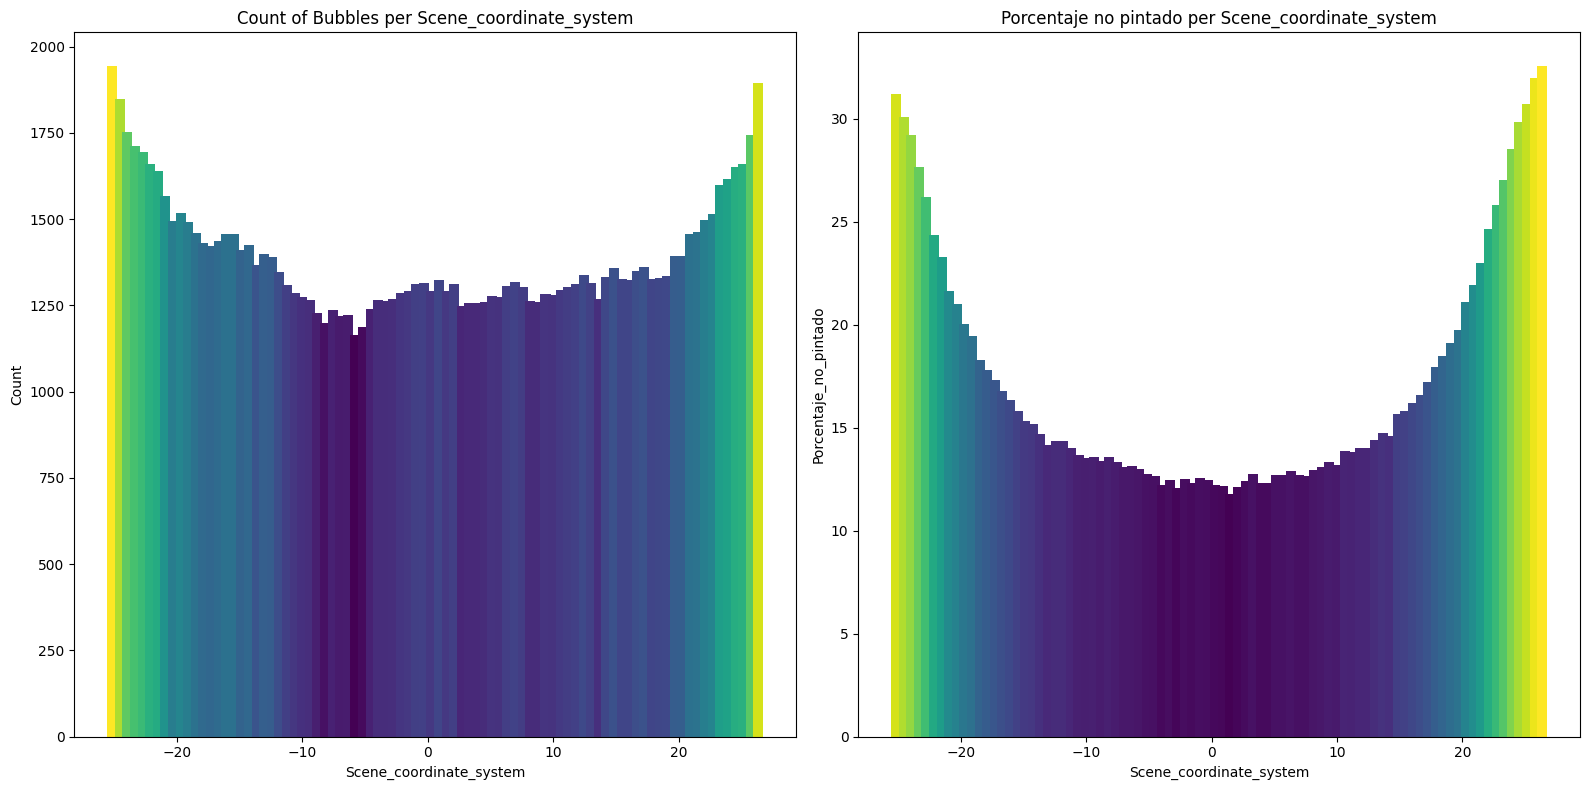

In [23]:
# Define a function to determine the color based on the count value using a gradient
def get_color(value, min_value, max_value):
    # Normalize the value to be between 0 and 1
    normalized_value = (value - min_value) / (max_value - min_value)
    # Convert the normalized value to a color using a colormap
    colormap = plt.cm.viridis
    return colormap(normalized_value)

# Get the minimum and maximum values of the 'Count' column
min_count_xz = count_table_xz['Count'].min()
max_count_xz = count_table_xz['Count'].max()

# Apply the color function to each value in the 'Count' column
colors_count_xz = count_table_xz['Count'].apply(lambda x: get_color(x, min_count_xz, max_count_xz))

# Get the minimum and maximum values of the 'Porcentaje_no_pintado' column
min_porcentaje_xz = count_table_xz['Porcentaje_no_pintado'].min()
max_porcentaje_xz = count_table_xz['Porcentaje_no_pintado'].max()

# Apply the color function to each value in the 'Porcentaje_no_pintado' column
colors_porcentaje_xz = count_table_xz['Porcentaje_no_pintado'].apply(lambda x: get_color(x, min_porcentaje_xz, max_porcentaje_xz))

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Plot the count data with the correct color array
axs[0].bar(count_table_xz['Scene_coordinate_system'], count_table_xz['Count'], color=colors_count_xz)
axs[0].set_xlabel('Scene_coordinate_system')
axs[0].set_ylabel('Count')
axs[0].set_title('Count of Bubbles per Scene_coordinate_system')

# Plot the porcentaje no pintado data with the correct color array
axs[1].bar(count_table_xz['Scene_coordinate_system'], count_table_xz['Porcentaje_no_pintado'], color=colors_porcentaje_xz)
axs[1].set_xlabel('Scene_coordinate_system')
axs[1].set_ylabel('Porcentaje_no_pintado')
axs[1].set_title('Porcentaje no pintado per Scene_coordinate_system')

# Adjust layout
plt.tight_layout()
plt.show()



Creating a new table, based of the images YZ

In [13]:
  # Count the occurrences of each unique value in the 'Imagen_idobject_substr' column
df_yz =df[(df['Coordenate_type'] == 'yz')  & ((df['Imagen_idobject_substr'] > 6) & (df['Imagen_idobject_substr'] < 92))]
count_table_yz = df_yz['Imagen_idobject_substr'].value_counts().reset_index()
count_table_yz.columns = ['Imagen_idobject_substr', 'Count']
    
    # Calculate the average 'Porcentaje_no_pintado' for each 'Imagen_idobject_substr'
average_porcentaje_no_pintado_yz = df_yz.groupby('Imagen_idobject_substr')['Porcentaje_no_pintado'].mean().reset_index()
    
    # Merge the average 'Porcentaje_no_pintado' with the count table
count_table_yz = pd.merge(count_table_yz, average_porcentaje_no_pintado_yz, on='Imagen_idobject_substr')
    
    # Sort the table by 'Imagen_idobject_substr'
count_table_yz = count_table_yz.sort_values(by='Imagen_idobject_substr')
    # Convert 'Imagen_idobject_substr' to numeric and sort the table by it
count_table_yz['Imagen_idobject_substr'] = pd.to_numeric(count_table_yz['Imagen_idobject_substr'])
count_table_yz = count_table_yz.sort_values(by='Imagen_idobject_substr')
    # Add an extra column with values increasing by 0.50505 starting from -23.48485 for Imagen_idobject_substr starting from 3
start_value_yz = -30.00000
increment_yz = 0.60606
count_table_yz['Scene_coordinate_system'] = start_value_yz + increment_yz * (count_table_yz['Imagen_idobject_substr'])
    # Minimum and maximum values of 'Diametro_mm' for each 'Imagen_idobject_substr'
min_diametro_mm_yz = df_yz.groupby('Imagen_idobject_substr')['Diametro_mm'].min().reset_index()
max_diametro_mm_yz = df_yz.groupby('Imagen_idobject_substr')['Diametro_mm'].max().reset_index()
average_diametro_mm_yz = df_yz.groupby('Imagen_idobject_substr')['Diametro_mm'].mean().reset_index()
average_area_mm2_yz = df_yz.groupby('Imagen_idobject_substr')['Area_mm2'].mean().reset_index()
mode_class_id_yz = df_yz.groupby('Imagen_idobject_substr')['Class_id'].agg(lambda x: x.value_counts().index[0]).reset_index()
    # Merge the minimum and maximum values of 'Diametro_mm' with the count table
count_table_yz = pd.merge(count_table_yz, min_diametro_mm_yz, on='Imagen_idobject_substr')
count_table_yz = pd.merge(count_table_yz, max_diametro_mm_yz, on='Imagen_idobject_substr')
count_table_yz= pd.merge(count_table_yz, average_diametro_mm_yz, on='Imagen_idobject_substr')
count_table_yz = pd.merge(count_table_yz, mode_class_id_yz, on='Imagen_idobject_substr')
count_table_yz = pd.merge(count_table_yz, average_area_mm2_yz, on='Imagen_idobject_substr')
    # Rename the columns
count_table_yz = count_table_yz.rename(columns={'Diametro_mm_x': 'Min_Diametro_mm', 'Diametro_mm_y': 'Max_Diametro_mm',
    'Average_DiametAo_mm': 'Average_Diametro_mm', 'Class_id': 'Mode_Class_id'})
    # Print the first 5 rows of the count table
print(count_table_yz.head())

   Imagen_idobject_substr  Count  Porcentaje_no_pintado  \
0                       7   1797              31.340207   
1                       8   1699              29.808912   
2                       9   1674              28.997346   
3                      10   1617              27.611662   
4                      11   1538              26.133118   

   Scene_coordinate_system  Min_Diametro_mm  Max_Diametro_mm  Diametro_mm  \
0                -25.75758         0.088019         1.297977     0.461914   
1                -25.15152         0.088019         1.261893     0.481312   
2                -24.54546         0.088019         1.922207     0.491070   
3                -23.93940         0.117076         1.953727     0.505155   
4                -23.33334         0.135921         1.562753     0.527836   

   Mode_Class_id  Area_mm2  
0              2  0.181374  
1              2  0.196898  
2              2  0.206500  
3              2  0.218362  
4              2  0.234341  


C:\Users\yourk\AppData\Local\Temp\ipykernel_18816\3344172513.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means_yz = count_table_yz.groupby('Group')['Diametro_mm'].mean()


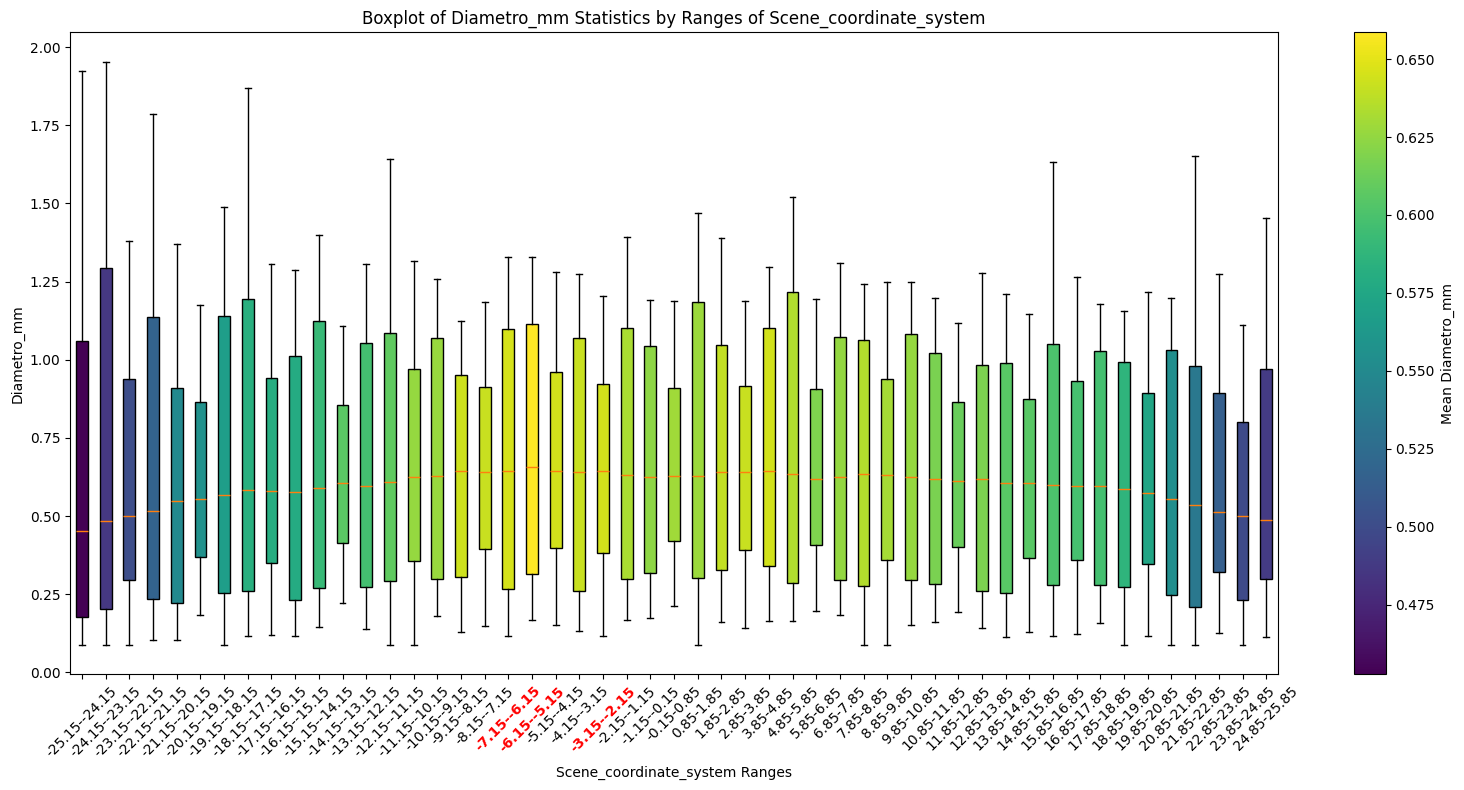

In [47]:
# Create bins for grouping 'Scene_coordinate_system' into ranges
bins = np.arange(count_table_yz['Scene_coordinate_system'].min(), 
                 count_table_yz['Scene_coordinate_system'].max() + 1, 
                 1)

# Assign each 'Scene_coordinate_system' to a bin range for each scene
count_table_yz['Group'] = pd.cut(count_table_yz['Scene_coordinate_system'], bins=bins, right=False)

# Prepare data for the boxplot
boxplot_data_yz = []

# Loop through each group and collect min, max, and average for boxplot
for group in count_table_yz['Group'].unique():
    group_data = count_table_yz[count_table_yz['Group'] == group]
    boxplot_data_yz.append(group_data[['Min_Diametro_mm', 'Max_Diametro_mm', 'Diametro_mm']].values.flatten())

# Get the means for each group to assign colors
means_yz = count_table_yz.groupby('Group')['Diametro_mm'].mean()

# Normalize the means to assign colors
norm = plt.Normalize(means_yz.min(), means_yz.max())
colors = plt.cm.viridis(norm(means_yz))


# Plot the boxplot
plt.figure(figsize=(16, 8))
boxplot = plt.boxplot(
    boxplot_data_yz,
    patch_artist=True,
    meanline=True,
)

# Customize X-axis with group ranges
group_labels_yz = [f"{interval.left:.2f}-{interval.right:.2f}" for interval in count_table_yz['Group'].cat.categories]
plt.xticks(ticks=range(1, len(group_labels_yz) + 1), labels=group_labels_yz, rotation=45)

# Add labels and title
plt.xlabel('Scene_coordinate_system Ranges')
plt.ylabel('Diametro_mm')
plt.title('Boxplot of Diametro_mm Statistics by Ranges of Scene_coordinate_system')

# Color each box based on the group's mean
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Highlight the top 3 groups with the highest average Diametro_mm
top3_groups_yz = means_yz.nlargest(3).index
for i, group in enumerate(count_table_yz['Group'].cat.categories):
    if group in top3_groups_yz:
        plt.gca().get_xticklabels()[i].set_color('red')
        plt.gca().get_xticklabels()[i].set_fontweight('bold')

# Add colorbar for the mean
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Mean Diametro_mm')

# Display the plot
plt.tight_layout()
plt.show()



Based on the conclusion for the week 1 and the stakeholders, and it is concluded the following 

* Eliminate the data obtanied of the image that the ray-x it is starting or finishing,it  only will be lost 6%-8% of the data, however the noise is going to be less passing aproximing of 97% to 99.5% of accuracy data. Because those images are only when it is getting closer to the object and the bubbles are hard or not valued
* Apply the methodology to other compuest and finishing the actual to starting to looking highlights between the bubbles and the propierties of materials 

Merged the tables XY,XZ,XY

In [14]:
import pandas as pd

# Asegúrate de que estas tablas existan: count_table_yz, count_table_xz, count_table_xy

# Añadir la columna de procedencia a cada tabla
count_table_yz['V'] = 'yz'
count_table_xz['V'] = 'xz'
count_table['V'] = 'xy'

# Combinar todas las tablas
merged_table = pd.concat([count_table_yz, count_table_xz, count_table], ignore_index=True)

# Mostrar las primeras filas de la tabla combinada
print(merged_table.head())


   Imagen_idobject_substr  Count  Porcentaje_no_pintado  \
0                       7   1797              31.340207   
1                       8   1699              29.808912   
2                       9   1674              28.997346   
3                      10   1617              27.611662   
4                      11   1538              26.133118   

   Scene_coordinate_system  Min_Diametro_mm  Max_Diametro_mm  Diametro_mm  \
0                -25.75758         0.088019         1.297977     0.461914   
1                -25.15152         0.088019         1.261893     0.481312   
2                -24.54546         0.088019         1.922207     0.491070   
3                -23.93940         0.117076         1.953727     0.505155   
4                -23.33334         0.135921         1.562753     0.527836   

   Mode_Class_id  Area_mm2   V  
0              2  0.181374  yz  
1              2  0.196898  yz  
2              2  0.206500  yz  
3              2  0.218362  yz  
4              2 

In [15]:

# Convertir la columna 'Group Source' a valores numéricos
group_source_mapping = {"xy": 0, "xz": 1, "yz": 2}
merged_table['V'] = merged_table['V'].map(group_source_mapping)
merged_table['V'] = merged_table['V'].astype(int)

print(merged_table['V'].dtype)


int32


In [16]:
csv_filename = "Results/merged_images_PU122.csv"
merged_table.to_csv(csv_filename, index=False)

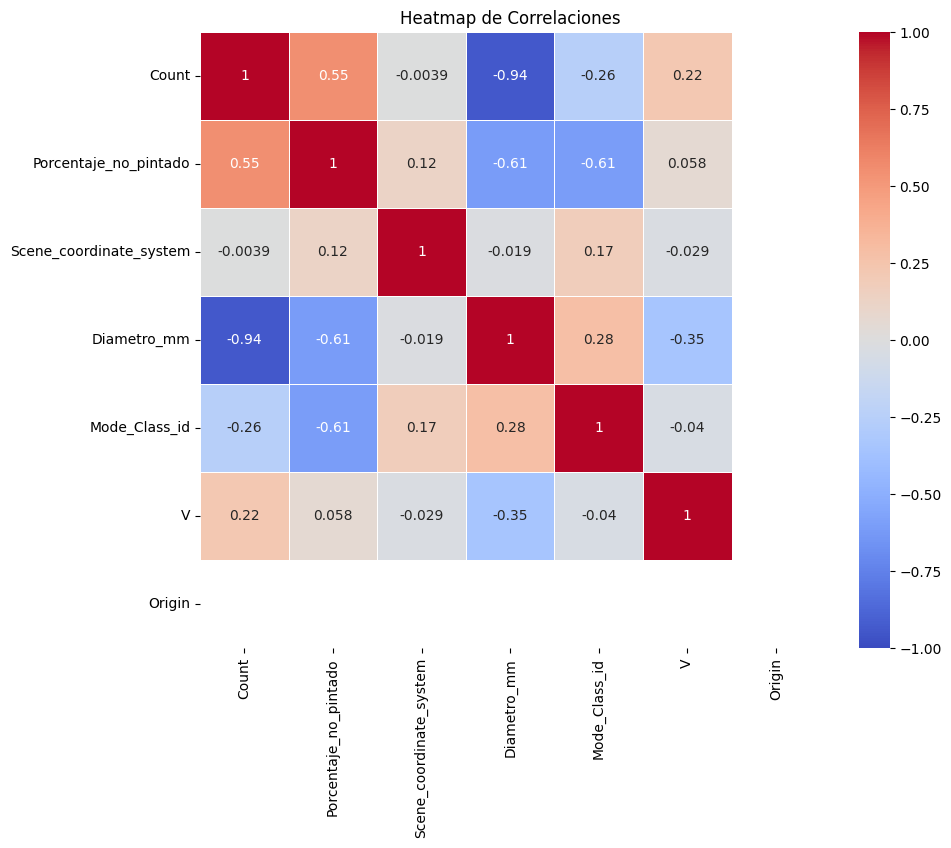

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
# Seleccionar únicamente columnas numéricas
numerical_data = merged_table.select_dtypes(include=['number'])

# Excluir columnas específicas que no deseas en la matriz de correlación
columns_to_exclude = ['Imagen_idobject_substr', 'Min_Diametro_mm','Max_Diametro_mm' ]  # Añade más si es necesario
numerical_data = merged_table.drop(columns=columns_to_exclude).select_dtypes(include=['number'])


# Calcular la matriz de correlación
correlation_matrix = numerical_data.corr()

# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 8))

# Crear el heatmap
sns.heatmap(correlation_matrix, 
            annot=True,         # Mostrar los valores numéricos
            cmap='coolwarm',    # Mapa de colores
            vmin=-1, vmax=1,    # Escala de correlación
            linewidths=0.5)     # Separación entre celdas

# Agregar título
plt.title('Heatmap de Correlaciones')

# Mostrar el gráfico
plt.show()

In [72]:
correlation_matrix_clean = correlation_matrix.fillna(0)

eigenvalues, eigenvectors = np.linalg.eig(correlation_matrix_clean)

eigen_df = pd.DataFrame(eigenvectors, columns=[f'Eigenvector_{i+1}' for i in range(len(eigenvectors))], index=correlation_matrix_clean.columns)
print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigen_df)


Eigenvalues:
[2.74068832 0.0476602  0.25037229 0.74791236 1.15091106 1.06245578
 0.        ]

Eigenvectors:
                         Eigenvector_1  Eigenvector_2  Eigenvector_3  \
Count                        -0.533936      -0.646570      -0.282904   
Porcentaje_no_pintado        -0.492978      -0.117849       0.747598   
Scene_coordinate_system      -0.001046       0.000771      -0.242023   
Diametro_mm                   0.557511      -0.743999       0.088754   
Mode_Class_id                 0.345942      -0.034727       0.535836   
V                            -0.203445      -0.115401       0.086541   
Origin                        0.000000       0.000000       0.000000   

                         Eigenvector_4  Eigenvector_5  Eigenvector_6  \
Count                         0.419055      -0.200888       0.029347   
Porcentaje_no_pintado        -0.161037       0.256402      -0.304150   
Scene_coordinate_system      -0.321420      -0.446144      -0.799417   
Diametro_mm                

* Lost 6% in the XY
* Lost 14.28% in the YZ